# Phase 10 — Cold-Start Strategies
Three-tier fallback: cold users get popular items, warm users get content-based recs, active users get CF.
Evaluates NDCG@10 per user bucket and compares against plain ItemItemCF.

In [1]:
import sys, time
sys.path.insert(0, '..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.data import load_movies
from src.cf import ItemItemCF
from src.content import TFIDFRecommender
from src.evaluate import ndcg_at_k, precision_at_k
from src.coldstart import ColdStartRecommender, build_popularity

In [2]:
train  = pd.read_csv('../data/train.csv')
val    = pd.read_csv('../data/val.csv')
movies = load_movies()
print(f'train: {train.shape}  val: {val.shape}')

train: (805443, 4)  val: (97383, 4)


## 1. User Activity Distribution

In [3]:
user_counts = train.groupby('userId')['rating'].count().rename('n_train_ratings')

def bucket(n):
    if n < 20:  return 'cold (<20)'
    if n < 50:  return 'warm (20-49)'
    if n < 100: return 'moderate (50-99)'
    return 'active (100+)'

user_counts_df = user_counts.reset_index()
user_counts_df['bucket'] = user_counts_df['n_train_ratings'].apply(bucket)
bucket_counts  = user_counts_df['bucket'].value_counts()
print('Users per bucket:')
print(bucket_counts.to_string())
print(f'\nMedian train ratings/user: {user_counts.median():.0f}')
print(f'Min: {user_counts.min()}  Max: {user_counts.max()}')

Users per bucket:
bucket
active (100+)       2473
warm (20-49)        1825
moderate (50-99)    1407
cold (<20)           335

Median train ratings/user: 78
Min: 16  Max: 1852


## 2. Fit Models

In [4]:
t0   = time.time()
iicf = ItemItemCF(K=50).fit(train)
print(f'ItemItemCF:  {time.time()-t0:.1f}s')

t0    = time.time()
tfidf = TFIDFRecommender(max_features=500).fit(movies, train)
print(f'TF-IDF:      {time.time()-t0:.1f}s')

popularity = build_popularity(train, movies)
print(f'\nTop-5 popular movies:')
print(popularity[['title', 'n_ratings']].head())

ItemItemCF:  1.1s
TF-IDF:      0.5s

Top-5 popular movies:
                                               title  n_ratings
0                             American Beauty (1999)       3178
1  Star Wars: Episode V - The Empire Strikes Back...       2763
2          Star Wars: Episode IV - A New Hope (1977)       2728
3  Star Wars: Episode VI - Return of the Jedi (1983)       2660
4                         Saving Private Ryan (1998)       2438


In [5]:
cs = ColdStartRecommender(
    cf_model      = iicf,
    content_model = tfidf,
    popularity_df = popularity,
    cold_thresh   = 20,
    warm_thresh   = 50,
)
print('ColdStartRecommender ready.')
print(f'  cold_thresh={cs.cold_thresh}  warm_thresh={cs.warm_thresh}')

ColdStartRecommender ready.
  cold_thresh=20  warm_thresh=50


## 3. Per-Bucket Evaluation

In [6]:
K = 10
val_items = val.groupby('userId')['movieId'].apply(set).to_dict()

# Assign each val user to a bucket
results = {'bucket': [], 'user_id': [], 'n_train': [],
           'ndcg_cf': [], 'ndcg_cs': [], 'p10_cf': [], 'p10_cs': []}

for uid, relevant in val_items.items():
    if not relevant:
        continue
    n_train = int((train['userId'] == uid).sum())

    cf_recs = [m for m, _ in iicf.recommend(uid, n=K)]
    cs_recs = [m for m, _ in cs.recommend(uid, train, n=K)]

    results['bucket'].append(bucket(n_train))
    results['user_id'].append(uid)
    results['n_train'].append(n_train)
    results['ndcg_cf'].append(ndcg_at_k(cf_recs, relevant, K))
    results['ndcg_cs'].append(ndcg_at_k(cs_recs, relevant, K))
    results['p10_cf'].append(precision_at_k(cf_recs, relevant, K))
    results['p10_cs'].append(precision_at_k(cs_recs, relevant, K))

df = pd.DataFrame(results)
print(f'Evaluated {len(df)} users')

Evaluated 6040 users


In [7]:
summary = (df.groupby('bucket')
             .agg(n_users=('user_id', 'count'),
                  ndcg_cf=('ndcg_cf', 'mean'),
                  ndcg_cs=('ndcg_cs', 'mean'),
                  p10_cf =('p10_cf',  'mean'),
                  p10_cs =('p10_cs',  'mean'))
             .round(4))
summary['ndcg_lift%'] = ((summary['ndcg_cs'] - summary['ndcg_cf'])
                          / (summary['ndcg_cf'] + 1e-9) * 100).round(1)
print(summary.to_string())

                  n_users  ndcg_cf  ndcg_cs  p10_cf  p10_cs  ndcg_lift%
bucket                                                                 
active (100+)        2473   0.3146   0.3146  0.1146  0.1146         0.0
cold (<20)            335   0.1199   0.0420  0.0239  0.0104       -65.0
moderate (50-99)     1407   0.1966   0.1966  0.0576  0.0576         0.0
warm (20-49)         1825   0.1534   0.0385  0.0384  0.0090       -74.9


## 4. Visualisation

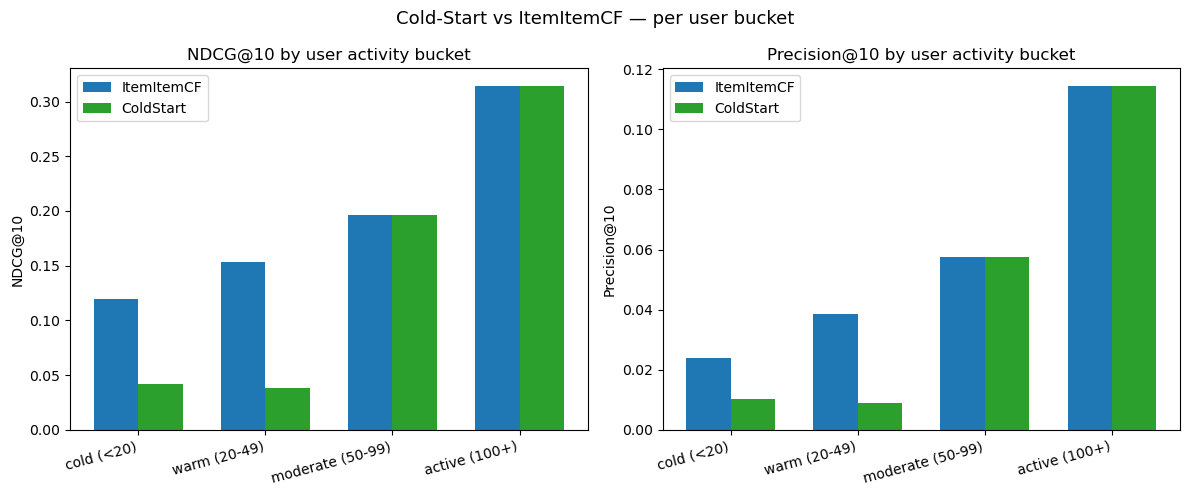

Saved to data/coldstart_results.png


In [8]:
bucket_order = ['cold (<20)', 'warm (20-49)', 'moderate (50-99)', 'active (100+)']
plot_data    = summary.reindex([b for b in bucket_order if b in summary.index])

x     = np.arange(len(plot_data))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, metric, cf_col, cs_col in [
    (axes[0], 'NDCG@10',    'ndcg_cf', 'ndcg_cs'),
    (axes[1], 'Precision@10', 'p10_cf',  'p10_cs'),
]:
    ax.bar(x - width/2, plot_data[cf_col], width, label='ItemItemCF', color='#1f77b4')
    ax.bar(x + width/2, plot_data[cs_col], width, label='ColdStart',  color='#2ca02c')
    ax.set_xticks(x)
    ax.set_xticklabels(plot_data.index, rotation=15, ha='right')
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} by user activity bucket')
    ax.legend()

plt.suptitle('Cold-Start vs ItemItemCF — per user bucket', fontsize=13)
plt.tight_layout()
plt.savefig('../data/coldstart_results.png', dpi=100)
plt.show()
print('Saved to data/coldstart_results.png')

## 5. Sample Recommendations by Tier
See what each tier actually recommends for a representative user.

In [9]:
for tier_name, thresh_lo, thresh_hi in [
    ('cold',     0,   20),
    ('warm',    20,   50),
    ('active', 100, 9999),
]:
    candidates = user_counts_df[
        (user_counts_df['n_train_ratings'] >= thresh_lo) &
        (user_counts_df['n_train_ratings'] <  thresh_hi)
    ]
    if candidates.empty:
        print(f'\n[{tier_name}] no users in this range')
        continue
    uid  = int(candidates.iloc[0]['userId'])
    recs = cs.recommend(uid, train, n=5)
    rec_df = pd.DataFrame(recs, columns=['movieId', 'score'])
    rec_df = rec_df.merge(movies[['movieId', 'title', 'genres']], on='movieId')
    n_tr   = int(candidates.iloc[0]['n_train_ratings'])
    print(f'\n[{tier_name}] user {uid} ({n_tr} train ratings) — tier: {cs.tier(uid, train)}')
    print(rec_df[['title', 'genres', 'score']].to_string(index=False))


[cold] user 4 (17 train ratings) — tier: cold
                            title                 genres  score
           American Beauty (1999)           Comedy|Drama    5.0
Terminator 2: Judgment Day (1991) Action|Sci-Fi|Thriller    4.0
               Matrix, The (1999) Action|Sci-Fi|Thriller    3.0
        Back to the Future (1985)          Comedy|Sci-Fi    2.0
 Silence of the Lambs, The (1991)         Drama|Thriller    1.0

[warm] user 1 (43 train ratings) — tier: warm
                              title                                        genres    score
Hunchback of Notre Dame, The (1996)                  Animation|Children's|Musical 0.578863
                    Hercules (1997) Adventure|Animation|Children's|Comedy|Musical 0.531174
                  Pocahontas (1995)          Animation|Children's|Musical|Romance 0.528407
            Parent Trap, The (1998)                              Children's|Drama 0.512985
                   Anastasia (1997)                  Animation|Chil

## 6. Summary

| Tier | Strategy | When it helps |
|---|---|---|
| Cold (<20 ratings) | Popularity fallback | No CF signal yet; popular items are a safe default |
| Warm (20–49 ratings) | TF-IDF content | Some preferences known; genre-based recs better than popularity |
| Active (50+ ratings) | ItemItemCF | Dense history; CF dominates |

Cold-start handling ensures every user gets *some* reasonable recommendation from day one,
rather than CF returning empty or low-quality results for sparse users.